# 트랜스포머의 구조와 분석 — 실습 문제
### 생성형 인공지능 10주차 | 학번: 2023101000  이름: 이준오

> **작성 방법**: 각 문제의 `# TODO` 부분을 채워 넣으세요. 바로 아래 **채점 셀**을 실행했을 때 `통과` 메시지가 나오면 정답입니다. 채점 셀은 수정하지 마세요.


## 실습 개요

| 문제 | 주제 | 강의자료 대응 |
|---|---|---|
| Q1 | 워드피스 토큰화 · 어휘 사전 · 원 핫 인코딩 | 트랜스포머의 입력 - 토큰화 |
| Q2 | 토큰 임베딩 · 내적 · 코사인 유사도 | 토큰간 관계 설정 / 토큰 임베딩 |
| Q3 | 위치 인코딩(Positional Encoding) | 위치 인코딩 - 토큰 임베딩 벡터 |
| Q4 | 점곱 어텐션(Scaled Dot-Product Attention) | 멀티헤드 어텐션의 키와 점곱 어텐션 |
| Q5 | 멀티헤드 어텐션(8개 헤드의 결합) | 멀티헤드 어텐션의 가치와 어텐션 헤드 |
| Q6 | 잔차 연결 · 층 정규화 · 앞먹임 신경망 → 인코더 블록 | 정규화와 앞먹임신경망 / 셀프 어텐션 |
| Q7 | 마스크드 멀티헤드 어텐션 · 인코더-디코더 어텐션 | 트랜스포머의 디코더 / 인코더와 디코더 결합 |
| Q8 | 출력층 · 손실 함수 · 초모수와 파라미터 수 | 트랜스포머의 출력 / 인코더의 반복과 초모수 |

**환경**: Google Colab (numpy, matplotlib만 사용 — 별도 설치 불필요)
**예시 문장**: `"I am studying Transformer."` → 독일어 `"Ich studiere Transformer."` (강의자료 예시와 동일)

---
## 0. 공통 설정

강의자료의 초모수(hyperparameter)를 그대로 사용합니다.
- 워드 임베딩 차원 `d_model = 512`
- 어텐션 헤드 수 `h = 8` → 헤드당 차원 `d_k = 512 / 8 = 64`
- 앞먹임 신경망 은닉층 `d_ff = 2048`
- 인코더/디코더 반복 횟수 `N = 6`
- 어휘 사전 크기 `V = 37,000` (영어-독일어 번역 기준)

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True, linewidth=140)

# ---- 강의자료 예시 ----
SENTENCE   = "I am studying Transformer."
TOKENS     = ["I", "am", "study", "##ing", "Transformer"]   # 워드피스 토큰화 결과(5개 토큰)

# ---- 트랜스포머 초모수 ----
D_MODEL    = 512    # 워드 임베딩 벡터의 차원
N_HEADS    = 8      # 어텐션 헤드의 수
D_K        = D_MODEL // N_HEADS   # 헤드 하나가 다루는 차원 = 64
D_FF       = 2048   # 앞먹임 신경망 은닉층 노드 수
N_LAYERS   = 6      # 인코더(디코더) 반복 횟수
VOCAB_SIZE = 37000  # 어휘 사전 크기

print(f"문장      : {SENTENCE}")
print(f"토큰      : {TOKENS}  (총 {len(TOKENS)}개)")
print(f"d_model={D_MODEL}, h={N_HEADS}, d_k={D_K}, d_ff={D_FF}, N={N_LAYERS}, V={VOCAB_SIZE}")

문장      : I am studying Transformer.
토큰      : ['I', 'am', 'study', '##ing', 'Transformer']  (총 5개)
d_model=512, h=8, d_k=64, d_ff=2048, N=6, V=37000


---
# Q1. 워드피스 토큰화 · 어휘 사전 · 원 핫 인코딩

강의자료 요약
- **토큰화**: 문장을 의미 있는 단위로 분할. 대표 기법은 **바이트 페어 인코딩(BPE)** 과 **워드 피스(WP)**.
- 워드피스는 단어를 최장 일치 기준으로 쪼개고, 단어 중간부터 시작하는 조각에는 `##` 을 붙인다.
  예) `studying` → `study` + `##ing`
- **어휘 사전(vocabulary)** 은 토큰마다 번호를 부여한 것이고, 그 번호를 이용해 **원 핫 벡터**를 만든다.
- 원 핫 벡터는 *단일 수치를 벡터로 표현한 것일 뿐 벡터 자체에는 의미가 없다* → 임의의 두 토큰을 내적하면 **0**.

### 요구사항
1. `wordpiece_tokenize(word, vocab)` : 한 단어를 **최장 일치 우선(longest-match-first)** 으로 토큰화. 두 번째 조각부터는 `##` 접두어를 붙인다. 어떤 방법으로도 쪼갤 수 없으면 `["[UNK]"]` 를 반환.
2. `build_vocab(vocab_list)` : 토큰 → 정수 id 사전을 만든다 (리스트 순서대로 0번부터).
3. `encode(tokens, token2id)` : 토큰 리스트를 id 리스트로 변환 (없으면 `[UNK]` id).
4. `one_hot(ids, vocab_size)` : `(len(ids), vocab_size)` 모양의 원 핫 행렬 반환.

In [22]:
VOCAB_LIST = ["[PAD]", "[UNK]", "[CLS]", "[SEP]",
              "I", "am", "study", "Transform", "Transformer", ".",
              "##ing", "##er", "##s", "##ed", "##y",
              "Ich", "studiere", "can", "##'t", "stand", "the"]

def wordpiece_tokenize(word, vocab):
    """단어 하나를 워드피스(최장 일치 우선) 방식으로 토큰화한다."""
    tokens = []
    start = 0
    while start < len(word):
        found = None
        for end in range(len(word), start, -1):
            piece = word[start:end] if start == 0 else "##" + word[start:end]
            if piece in vocab:
                found = piece
                start = end
                break
        if found is None:
            return ["[UNK]"]
        tokens.append(found)
    return tokens


def build_vocab(vocab_list):
    """토큰 리스트를 {토큰: id} 사전으로 변환한다."""
    return {token: index for index, token in enumerate(vocab_list)}


def encode(tokens, token2id):
    """토큰 리스트를 정수 id 리스트로 변환한다."""
    unk_id = token2id.get("[UNK]", 0)
    return [token2id.get(token, unk_id) for token in tokens]


def one_hot(ids, vocab_size):
    """id 리스트를 원 핫 행렬로 변환한다."""
    ids = np.asarray(ids, dtype=int)
    result = np.zeros((len(ids), vocab_size), dtype=float)
    result[np.arange(len(ids)), ids] = 1.0
    return result


token2id = build_vocab(VOCAB_LIST)
V_SMALL  = len(VOCAB_LIST)

print("studying    ->", wordpiece_tokenize("studying", set(VOCAB_LIST)))
print("Transformer ->", wordpiece_tokenize("Transformer", set(VOCAB_LIST)))

ids = encode(TOKENS, token2id)
OH  = one_hot(ids, V_SMALL)
print("토큰 :", TOKENS)
print("id   :", ids)
print("원 핫 행렬 모양 :", OH.shape)
print("'I'와 'am'의 원 핫 벡터 내적 :", float(OH[0] @ OH[1]))


studying    -> ['study', '##ing']
Transformer -> ['Transformer']
토큰 : ['I', 'am', 'study', '##ing', 'Transformer']
id   : [4, 5, 6, 10, 8]
원 핫 행렬 모양 : (5, 21)
'I'와 'am'의 원 핫 벡터 내적 : 0.0


In [23]:
# ===== Q1 채점 =====
_v = set(VOCAB_LIST)
assert wordpiece_tokenize("studying", _v)    == ["study", "##ing"],   "studying -> ['study','##ing']"
assert wordpiece_tokenize("Transformer", _v) == ["Transformer"],      "사전에 통째로 있으면 쪼개지 않는다"
assert wordpiece_tokenize("studys", _v)      == ["study", "##s"]
assert wordpiece_tokenize("zzz", _v)         == ["[UNK]"]
assert build_vocab(VOCAB_LIST)["[UNK]"] == 1 and build_vocab(VOCAB_LIST)["I"] == 4
assert encode(["I", "am", "고양이"], token2id) == [4, 5, 1], "사전에 없는 토큰은 [UNK]"
assert OH.shape == (len(TOKENS), V_SMALL)
assert np.allclose(OH.sum(axis=1), 1.0),        "원 핫 벡터의 원소 합은 1"
assert np.isclose(OH[0] @ OH[1], 0.0),          "서로 다른 원 핫 벡터의 내적은 0"
assert np.allclose(OH @ OH.T, np.eye(len(TOKENS)))
print("✅ Q1 통과")

✅ Q1 통과


---
# Q2. 토큰 임베딩 · 내적 · 코사인 유사도

강의자료 요약
- 원 핫 벡터에 **의미를 부여하는 과정**이 토큰 임베딩이며, 대표 기법이 **CBOW**(주변 토큰으로 중심 토큰 예측)와 **Skip-Gram**(중심 토큰으로 주변 토큰 예측)이다.
- 임베딩 행렬 `E` 의 **행 벡터**가 특정 토큰의 임베딩 벡터이며, 실제 트랜스포머에서는 512차원을 사용한다.
- 임베딩 벡터끼리 **내적**하면 토큰 간 관계(유사도)를 얻는다. *내적 결과가 높을수록 유사한 관계이며, 자기 자신이 가장 높을 수 있다.*

아래 `E_DEMO` 는 강의자료 슬라이드의 4차원 임베딩 예시 값입니다.

### 요구사항
1. `embed_lookup(one_hot_matrix, E)` : **원 핫 행렬과 임베딩 행렬의 곱**이 곧 행 조회(lookup)임을 코드로 확인.
2. `dot_similarity(X)` : 모든 토큰 쌍의 내적 행렬 `(n, n)` 반환.
3. `cosine_similarity(X)` : 모든 토큰 쌍의 코사인 유사도 행렬 반환. (0으로 나누는 것 방지)
4. 강의자료의 값 `[1.16, 0.38, 0.49, 0.605, 0.57]` 을 재현하고, **내적 기준**과 **코사인 기준**에서 `I` 와 가장 유사한 (자기 자신 제외) 토큰이 각각 무엇인지 출력.

In [24]:
# 강의자료의 4차원 임베딩 예시 (행 = 토큰: I, am, study, ##ing, Transformer)
E_DEMO = np.array([
    [0.30, 0.10, 0.50, 0.90],
    [0.40, 0.20, 0.30, 0.10],
    [0.90, 0.80, 0.10, 0.10],
    [0.20, 0.70, 0.05, 0.50],
    [0.10, 0.30, 0.30, 0.40],
])

def embed_lookup(one_hot_matrix, E):
    return np.asarray(one_hot_matrix) @ np.asarray(E)


def dot_similarity(X):
    return np.asarray(X) @ np.asarray(X).T


def cosine_similarity(X):
    X = np.asarray(X)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    normalized = X / np.maximum(norms, 1e-12)
    return normalized @ normalized.T

E_small = np.random.randn(V_SMALL, 8)
assert np.allclose(embed_lookup(OH, E_small), E_small[ids])
print("원 핫 행렬 @ 임베딩 행렬  ==  임베딩 행 조회  ->  동일함 확인")

D = dot_similarity(E_DEMO)
print("\n'I' 토큰 벡터와 모든 토큰 벡터의 내적 :", D[0])
print("강의자료 값                          : [1.16  0.38  0.49  0.605 0.57 ]")

C = cosine_similarity(E_DEMO)
print("\n[내적 유사도 행렬]\n", D)
print("\n[코사인 유사도 행렬]\n", C)

d_rank = int(np.argsort(D[0][1:]).__getitem__(-1) + 1)
c_rank = int(np.argsort(C[0][1:]).__getitem__(-1) + 1)
print(f"\n내적   기준 'I'와 가장 유사한 토큰 : {TOKENS[d_rank]}")
print(f"코사인 기준 'I'와 가장 유사한 토큰 : {TOKENS[c_rank]}")


원 핫 행렬 @ 임베딩 행렬  ==  임베딩 행 조회  ->  동일함 확인

'I' 토큰 벡터와 모든 토큰 벡터의 내적 : [1.16  0.38  0.49  0.605 0.57 ]
강의자료 값                          : [1.16  0.38  0.49  0.605 0.57 ]

[내적 유사도 행렬]
 [[1.16  0.38  0.49  0.605 0.57 ]
 [0.38  0.3   0.56  0.285 0.23 ]
 [0.49  0.56  1.47  0.795 0.4  ]
 [0.605 0.285 0.795 0.782 0.445]
 [0.57  0.23  0.4   0.445 0.35 ]]

[코사인 유사도 행렬]
 [[1.    0.644 0.375 0.635 0.895]
 [0.644 1.    0.843 0.588 0.71 ]
 [0.375 0.843 1.    0.741 0.558]
 [0.635 0.588 0.741 1.    0.85 ]
 [0.895 0.71  0.558 0.85  1.   ]]

내적   기준 'I'와 가장 유사한 토큰 : ##ing
코사인 기준 'I'와 가장 유사한 토큰 : Transformer


In [25]:
# ===== Q2 채점 =====
assert np.allclose(embed_lookup(OH, E_small), E_small[ids])
assert np.allclose(D[0], [1.16, 0.38, 0.49, 0.605, 0.57]), "강의자료의 내적 값과 달라요"
assert D.shape == (5, 5) and np.allclose(D, D.T), "유사도 행렬은 대칭"
assert np.allclose(np.diag(C), 1.0), "자기 자신과의 코사인 유사도는 1"
assert (C <= 1.0 + 1e-9).all() and (C >= -1.0 - 1e-9).all()
assert np.allclose(cosine_similarity(np.array([[1.0, 0.0], [0.0, 1.0]])), np.eye(2))
assert np.allclose(cosine_similarity(np.array([[1.0, 1.0], [2.0, 2.0]])), np.ones((2, 2)))
assert d_rank == 3, "내적 기준 1위는 '##ing' 입니다 (자기 자신 제외)"
assert c_rank == 4, "코사인 기준 1위는 'Transformer' 입니다 (자기 자신 제외)"
assert d_rank != c_rank, "두 기준의 결과가 다르다는 점이 이 문제의 핵심입니다"
print("✅ Q2 통과")

✅ Q2 통과


---
# Q3. 위치 인코딩 (Positional Encoding)

강의자료 요약
- 순환신경망은 토큰을 **순차적으로** 넣기 때문에 순서 정보가 자연히 들어가지만, 트랜스포머는 5개 토큰을 **한 번에** 넣으므로 위치 정보가 누락된다.
- 순서 번호를 그대로 쓰면 문장이 길어질수록 값이 커지고, 원 핫 방식은 문장 최대 길이를 미리 정해야 하며 계산량이 크다.
- 그래서 **삼각함수**를 사용한다. 서로 다른 원소가 서로 다른 주기를 갖게 하여 **중복을 최대한 방지**하면서 위치를 부여한다.

$$PE_{(pos,\;2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad
PE_{(pos,\;2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- 위치 인코딩은 워드 임베딩과 **동일한 512차원**이며, **원소별 덧셈**으로 결합되어 인코더의 입력이 된다.
  > 참고: 강의자료는 원소 번호를 1부터 세어 "홀수 번째=코사인, 짝수 번째=사인"으로 설명합니다. 위 수식(0부터 세는 표기)과 동일한 내용입니다.

### 요구사항
1. `positional_encoding(max_len, d_model)` : `(max_len, d_model)` 위치 인코딩 행렬 반환 (반복문 대신 브로드캐스팅 권장).
2. `make_encoder_input(token_ids, E, PE)` : 워드 임베딩 + 위치 인코딩(원소별 합)으로 인코더 입력 생성.
3. `"I can't stand the stand"` 처럼 **같은 토큰이 다른 위치**에 나올 때, 위치 인코딩 전에는 벡터가 같고 후에는 달라짐을 확인.
4. 위치 인코딩 행렬을 히트맵으로 시각화.

위치 인코딩 행렬 : (50, 512)
PE[0, :6] = [0. 1. 0. 1. 0. 1.]
PE[1, :6] = [0.841 0.54  0.822 0.57  0.802 0.597]
값의 범위 : [-1.000, 1.000]

인코더 입력 : (5, 512)

'stand'(3번 위치) vs 'stand'(5번 위치)
  위치 인코딩 전 두 벡터가 동일한가?  True
  위치 인코딩 후 두 벡터가 동일한가?  False


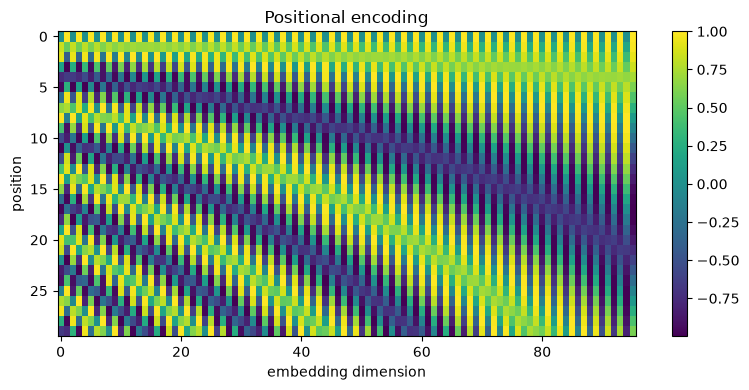

In [26]:
def positional_encoding(max_len, d_model):
    """(max_len, d_model) 크기의 위치 인코딩 행렬."""
    positions = np.arange(max_len)[:, None]
    dimensions = np.arange(0, d_model, 2)[None, :]
    angles = positions / np.power(10000.0, dimensions / d_model)
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(angles)
    pe[:, 1::2] = np.cos(angles[:, :pe[:, 1::2].shape[1]])
    return pe


def make_encoder_input(token_ids, E, PE):
    """워드 임베딩 + 위치 인코딩."""
    token_ids = np.asarray(token_ids)
    return E[token_ids] + PE[:len(token_ids)]

PE = positional_encoding(50, D_MODEL)
print("위치 인코딩 행렬 :", PE.shape)
print("PE[0, :6] =", PE[0, :6])
print("PE[1, :6] =", PE[1, :6])
print("값의 범위 : [%.3f, %.3f]" % (PE.min(), PE.max()))

E_FULL = np.random.randn(V_SMALL, D_MODEL) * 0.1
X_enc  = make_encoder_input(ids, E_FULL, PE)
print("\n인코더 입력 :", X_enc.shape)

sent2  = ["I", "can", "##'t", "stand", "the", "stand"]
ids2   = encode(sent2, token2id)
emb2   = E_FULL[ids2]
inp2   = make_encoder_input(ids2, E_FULL, PE)
print("\n'stand'(3번 위치) vs 'stand'(5번 위치)")
print("  위치 인코딩 전 두 벡터가 동일한가? ", np.allclose(emb2[3], emb2[5]))
print("  위치 인코딩 후 두 벡터가 동일한가? ", np.allclose(inp2[3], inp2[5]))

plt.figure(figsize=(8, 4))
plt.imshow(PE[:30, :96], aspect="auto", cmap="viridis")
plt.colorbar(); plt.xlabel("embedding dimension"); plt.ylabel("position")
plt.title("Positional encoding")
plt.tight_layout(); plt.show()


In [27]:
# ===== Q3 채점 =====
_pe = positional_encoding(10, 16)
assert _pe.shape == (10, 16)
assert np.isclose(_pe[0, 0], 0.0) and np.isclose(_pe[0, 1], 1.0), "pos=0 이면 sin(0)=0, cos(0)=1"
assert np.isclose(_pe[1, 0], np.sin(1.0)) and np.isclose(_pe[1, 1], np.cos(1.0))
assert np.isclose(_pe[3, 2], np.sin(3 / 10000 ** (2 / 16))), "2i/d_model 지수를 확인하세요"
assert np.isclose(_pe[3, 3], np.cos(3 / 10000 ** (2 / 16)))
assert (_pe >= -1).all() and (_pe <= 1).all(), "삼각함수 값은 -1~1"
assert np.allclose(_pe[:, 0::2] ** 2 + _pe[:, 1::2] ** 2, 1.0), "같은 주파수의 sin^2+cos^2=1"
assert PE.shape == (50, D_MODEL) and X_enc.shape == (5, D_MODEL)
assert np.allclose(X_enc, E_FULL[ids] + PE[:5]), "임베딩과 위치 인코딩은 '원소별 덧셈'으로 결합"
assert np.allclose(emb2[3], emb2[5]) and not np.allclose(inp2[3], inp2[5])
print("✅ Q3 통과")

✅ Q3 통과


---
# Q4. 점곱 어텐션 (Scaled Dot-Product Attention)

강의자료 요약
- 하나의 어텐션 헤드는 **쿼리(Query) · 키(Key) · 가치(Value)** 로 관계를 설정한다.
- 쿼리는 *관계를 설정하는 대상 토큰*, 키는 *비교 대상이 되는 모든 토큰*, 가치는 *실제로 가져올 정보*이다.
- 어텐션 점수 = 쿼리 벡터와 키 벡터의 **내적**. 값이 지나치게 커지는 것을 막기 위해 **키 벡터 차원의 제곱근** $\sqrt{d_k}$ 로 나눈다.
- 소프트맥스로 확률로 바꾼 것이 **어텐션 가중치**이다.

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V$$

### 요구사항
1. `softmax(x, axis=-1)` : **수치적으로 안정한** 소프트맥스 (최댓값을 빼고 지수화).
2. `scaled_dot_product_attention(Q, K, V, mask=None)` : 출력과 어텐션 가중치를 함께 반환. `mask` 가 `True` 인 위치는 소프트맥스 전에 `-inf` 로 만든다.
3. 강의자료 예시 재현 : 점수 `[20, 30, 8, 2, 1]`, `d_k = 4` → `√4 = 2` 로 나눈 뒤 소프트맥스 → `[0.007, 0.993, 0, 0, 0]`.
4. $\sqrt{d_k}$ 로 **나누지 않으면** 어텐션 가중치가 어떻게 되는지 최댓값을 비교해 확인.

In [28]:
def softmax(x, axis=-1):
    """수치적으로 안정한 소프트맥스. (최댓값을 빼고 지수화할 것)"""
    x = np.asarray(x)
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    """Q:(nq,dk), K:(nk,dk), V:(nk,dv) -> output, weights.
    mask=True인 위치는 참조를 금지합니다.
    """
    scores = Q @ K.T / np.sqrt(Q.shape[-1])
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

raw_scores = np.array([20.0, 30.0, 8.0, 2.0, 1.0])
d_k_demo   = 4
scaled     = raw_scores / np.sqrt(d_k_demo)
w_demo     = softmax(scaled)
print("어텐션 점수          :", raw_scores)
print("sqrt(d_k)=2 로 나눔  :", scaled)
print("소프트맥스 결과      :", np.round(w_demo, 3))

w_noscale = softmax(raw_scores)
print("\n[스케일링 X] 최대 가중치 = %.6f" % w_noscale.max())
print("[스케일링 O] 최대 가중치 = %.6f" % w_demo.max())

W_q = np.random.randn(D_MODEL, D_K) * 0.05
W_k = np.random.randn(D_MODEL, D_K) * 0.05
W_v = np.random.randn(D_MODEL, D_K) * 0.05
Q  = X_enc @ W_q
K  = X_enc @ W_k
Vv = X_enc @ W_v
head_out, attn_w = scaled_dot_product_attention(Q, K, Vv)
print("\nQ, K, V 모양 :", Q.shape, K.shape, Vv.shape)
print("헤드 출력    :", head_out.shape)
print("어텐션 가중치(셀프 어텐션 행렬) :\n", np.round(attn_w, 3))


어텐션 점수          : [20. 30.  8.  2.  1.]
sqrt(d_k)=2 로 나눔  : [10.  15.   4.   1.   0.5]
소프트맥스 결과      : [0.007 0.993 0.    0.    0.   ]

[스케일링 X] 최대 가중치 = 0.999955
[스케일링 O] 최대 가중치 = 0.993289

Q, K, V 모양 : (5, 64) (5, 64) (5, 64)
헤드 출력    : (5, 64)
어텐션 가중치(셀프 어텐션 행렬) :
 [[0.233 0.208 0.173 0.162 0.225]
 [0.263 0.232 0.178 0.144 0.183]
 [0.255 0.222 0.18  0.151 0.193]
 [0.253 0.224 0.181 0.152 0.191]
 [0.251 0.226 0.188 0.154 0.181]]


In [29]:
# ===== Q4 채점 =====
assert np.allclose(softmax(np.array([0.0, 0.0])), [0.5, 0.5])
assert np.isfinite(softmax(np.array([1000.0, 1001.0]))).all(), "큰 값에서도 오버플로가 없어야 합니다"
_s2 = softmax(np.array([[1.0, 2.0], [3.0, 4.0]]), axis=-1)
assert np.allclose(_s2.sum(axis=-1), 1.0)
assert np.allclose(scaled, [10.0, 15.0, 4.0, 1.0, 0.5])
assert np.allclose(np.round(w_demo, 3), [0.007, 0.993, 0.0, 0.0, 0.0]), "강의자료 값과 달라요"
assert w_noscale.max() > w_demo.max(), "스케일링을 안 하면 분포가 더 뾰족해집니다"

_q = np.eye(3); _o, _w = scaled_dot_product_attention(_q, _q, np.arange(9.).reshape(3, 3))
assert _o.shape == (3, 3) and _w.shape == (3, 3)
assert np.allclose(_w.sum(axis=1), 1.0), "어텐션 가중치의 각 행의 합은 1"
_m = np.array([[False, True], [False, False]])
_o2, _w2 = scaled_dot_product_attention(np.eye(2), np.eye(2), np.eye(2), mask=_m)
assert np.isclose(_w2[0, 1], 0.0), "mask=True 위치의 가중치는 0"
assert head_out.shape == (5, D_K) and attn_w.shape == (5, 5)
print("✅ Q4 통과")

✅ Q4 통과


---
# Q5. 멀티헤드 어텐션 (8개 헤드의 결합)

강의자료 요약
- 어텐션 헤드는 각각 512×64 크기의 $W^Q, W^K, W^V$ 를 갖고 64차원 벡터를 산출한다.
- **8개의 헤드**가 만든 64차원 벡터를 **이어 붙이면(concat) 512차원**이 되고, 여기에 $W^O$ (512×512)를 곱해 최종 결과를 낸다.
- 즉 **멀티헤드 어텐션의 입력과 출력은 같은 512차원**이므로 인코더를 여러 번 반복할 수 있다.

### 요구사항
1. `init_mha_params(d_model, n_heads, seed)` : 헤드별 $W^Q, W^K, W^V$ 리스트와 $W^O$ 를 만들어 dict 로 반환.
2. `multi_head_attention(X_q, X_kv, params, mask=None)` : 헤드별로 어텐션을 계산 → 이어 붙임 → $W^O$ 곱. 출력과 헤드별 가중치 리스트를 반환.
   - `X_q` 와 `X_kv` 를 분리하면 셀프 어텐션(`X_q is X_kv`)과 인코더-디코더 어텐션을 모두 처리할 수 있다.
3. 출력이 입력과 **같은 (5, 512)** 모양임을 확인.
4. 멀티헤드 어텐션의 **학습 가능한 파라미터 개수**(편향 제외)를 계산: $4 \times d_{model}^2$.
5. 헤드 1개와 헤드 2개의 어텐션 가중치 행렬을 히트맵으로 그려 **헤드마다 다른 관계를 학습**함을 확인.

입력  : (5, 512)
멀티헤드 출력   : (5, 512)

멀티헤드 어텐션 파라미터 수 = 1,048,576


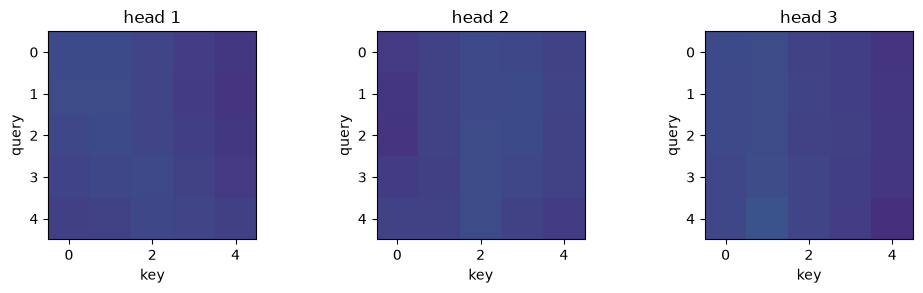

In [30]:
def init_mha_params(d_model, n_heads, seed=0):
    """멀티헤드 어텐션 가중치 초기화."""
    assert d_model % n_heads == 0
    rng = np.random.RandomState(seed)
    d_k = d_model // n_heads
    scale = 1.0 / np.sqrt(d_model)
    return {
        "Wq": [rng.randn(d_model, d_k) * scale for _ in range(n_heads)],
        "Wk": [rng.randn(d_model, d_k) * scale for _ in range(n_heads)],
        "Wv": [rng.randn(d_model, d_k) * scale for _ in range(n_heads)],
        "Wo": rng.randn(d_model, d_model) * scale,
        "n_heads": n_heads,
        "d_k": d_k,
        "d_model": d_model,
    }


def multi_head_attention(X_q, X_kv, params, mask=None):
    """헤드별 어텐션 -> concat -> Wo."""
    heads = []
    weights = []
    for Wq, Wk, Wv in zip(params["Wq"], params["Wk"], params["Wv"]):
        Q = X_q @ Wq
        K = X_kv @ Wk
        V = X_kv @ Wv
        head, weight = scaled_dot_product_attention(Q, K, V, mask=mask)
        heads.append(head)
        weights.append(weight)
    return np.concatenate(heads, axis=-1) @ params["Wo"], weights

enc_mha = init_mha_params(D_MODEL, N_HEADS, seed=1)
mha_out, head_ws = multi_head_attention(X_enc, X_enc, enc_mha)
print("입력  :", X_enc.shape)
print("멀티헤드 출력   :", mha_out.shape)

n_params = 4 * D_MODEL * D_MODEL
print("\n멀티헤드 어텐션 파라미터 수 = {:,}".format(n_params))

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, weights, title in zip(axes, head_ws[:3], ["head 1", "head 2", "head 3"]):
    ax.imshow(weights, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel("key"); ax.set_ylabel("query")
plt.tight_layout(); plt.show()


In [31]:
# ===== Q5 채점 =====
assert set(["Wq", "Wk", "Wv", "Wo", "n_heads", "d_k"]).issubset(enc_mha.keys())
assert len(enc_mha["Wq"]) == N_HEADS and enc_mha["Wq"][0].shape == (D_MODEL, D_K)
assert enc_mha["Wo"].shape == (D_MODEL, D_MODEL)
assert mha_out.shape == (5, D_MODEL), "멀티헤드 어텐션의 출력은 입력과 같은 차원"
assert len(head_ws) == N_HEADS and head_ws[0].shape == (5, 5)
for w in head_ws:
    assert np.allclose(w.sum(axis=1), 1.0)
assert not np.allclose(head_ws[0], head_ws[1]), "헤드마다 다른 관계를 학습해야 합니다"
assert n_params == 4 * D_MODEL * D_MODEL == 1048576

# 이어 붙이기(concat)가 실제로 일어났는지 확인 : Wo 를 단위행렬로 두면 concat 결과와 같아야 함
_p = init_mha_params(D_MODEL, N_HEADS, seed=1); _p["Wo"] = np.eye(D_MODEL)
_o, _ = multi_head_attention(X_enc, X_enc, _p)
_manual = np.concatenate(
    [scaled_dot_product_attention(X_enc @ _p["Wq"][h], X_enc @ _p["Wk"][h], X_enc @ _p["Wv"][h])[0]
     for h in range(N_HEADS)], axis=-1)
assert np.allclose(_o, _manual), "8개 헤드의 결과를 순서대로 이어 붙여야 합니다"

# 쿼리와 키/가치의 출처가 달라도 동작해야 함(인코더-디코더 어텐션 대비)
_cross, _cw = multi_head_attention(np.random.randn(2, D_MODEL), X_enc, enc_mha)
assert _cross.shape == (2, D_MODEL) and _cw[0].shape == (2, 5)
print("✅ Q5 통과")

✅ Q5 통과


---
# Q6. 잔차 연결 · 층 정규화 · 앞먹임 신경망 → 인코더 블록

강의자료 요약
- **잔차 연결(residual)**: `출력 = 입력 + 멀티헤드 어텐션을 거친 결과`. 깊은 모델의 **기울기 소실 문제**를 완화한다.
- **층 정규화(layer normalization)**: 출력 데이터의 **평균과 분산**을 이용해 값을 조정하여 학습을 돕는다.
- **앞먹임 신경망(FFN)**: 입력층 512 → 은닉층 2,048(2층) → 출력층 512. 8개 헤드에서 취합한 관계 정보로 더 복잡한 관계를 모사한다.
- 인코더 블록 = `LN(x + MHA(x))` → `LN(h + FFN(h))`, 그리고 이것을 **6번 반복**한다.

### 요구사항
1. `layer_norm(x, gamma, beta, eps=1e-6)` : **마지막 축** 기준으로 정규화 후 `gamma * x_hat + beta`.
2. `init_ffn_params(d_model, d_ff, seed)` / `feed_forward(x, params)` : `ReLU(xW1+b1)W2+b2`.
3. `encoder_layer(X, params)` : 잔차 연결 + 층 정규화를 포함한 인코더 블록 1개.
4. 인코더를 **6번 반복**해도 모양이 유지됨을 확인하고, 층 정규화 후 각 토큰 벡터의 평균≈0, 표준편차≈1 임을 확인.

In [32]:
def layer_norm(x, gamma, beta, eps=1e-6):
    """마지막 축 기준 층 정규화."""
    x = np.asarray(x)
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    normalized = (x - mean) / np.sqrt(var + eps)
    return gamma * normalized + beta


def init_ffn_params(d_model, d_ff, seed=0):
    rng = np.random.RandomState(seed)
    return {"W1": rng.randn(d_model, d_ff) * np.sqrt(2.0 / d_model), "b1": np.zeros(d_ff),
            "W2": rng.randn(d_ff, d_model) * np.sqrt(2.0 / d_ff),    "b2": np.zeros(d_model)}


def feed_forward(x, p):
    """앞먹임 신경망: 512 -> 2048 (ReLU) -> 512"""
    hidden = np.maximum(0.0, x @ p["W1"] + p["b1"])
    return hidden @ p["W2"] + p["b2"]


def init_encoder_layer(d_model, n_heads, d_ff, seed=0):
    return {"mha": init_mha_params(d_model, n_heads, seed),
            "ffn": init_ffn_params(d_model, d_ff, seed + 100),
            "g1": np.ones(d_model), "b1": np.zeros(d_model),
            "g2": np.ones(d_model), "b2": np.zeros(d_model)}


def encoder_layer(X, p):
    attn, weights = multi_head_attention(X, X, p["mha"])
    h = layer_norm(X + attn, p["g1"], p["b1"])
    f = feed_forward(h, p["ffn"])
    return layer_norm(h + f, p["g2"], p["b2"]), weights

enc_params = [init_encoder_layer(D_MODEL, N_HEADS, D_FF, seed=s) for s in range(N_LAYERS)]
H = X_enc
for li in range(N_LAYERS):
    H, _ = encoder_layer(H, enc_params[li])
    print(f"encoder layer {li + 1}: {H.shape}")
ENC_OUT = H
print("\n인코더 최종 출력 :", ENC_OUT.shape)
print("각 토큰 벡터의 평균     :", ENC_OUT.mean(axis=-1))
print("각 토큰 벡터의 표준편차 :", ENC_OUT.std(axis=-1))


encoder layer 1: (5, 512)
encoder layer 2: (5, 512)
encoder layer 3: (5, 512)
encoder layer 4: (5, 512)
encoder layer 5: (5, 512)
encoder layer 6: (5, 512)

인코더 최종 출력 : (5, 512)
각 토큰 벡터의 평균     : [-0. -0. -0. -0. -0.]
각 토큰 벡터의 표준편차 : [1. 1. 1. 1. 1.]


In [33]:
# ===== Q6 채점 =====
_x  = np.array([[1.0, 2.0, 3.0, 4.0], [10.0, 0.0, -5.0, 3.0]])
_ln = layer_norm(_x, np.ones(4), np.zeros(4))
assert np.allclose(_ln.mean(axis=-1), 0.0, atol=1e-5), "층 정규화 후 평균은 0"
assert np.allclose(_ln.std(axis=-1), 1.0, atol=1e-3),  "층 정규화 후 표준편차는 1"
assert np.allclose(layer_norm(_x, np.full(4, 2.0), np.full(4, 5.0)), _ln * 2.0 + 5.0), "gamma/beta 적용 확인"

_p = init_ffn_params(8, 16, seed=0)
assert feed_forward(np.random.randn(3, 8), _p).shape == (3, 8), "FFN의 입출력 차원은 같다"
_neg = feed_forward(np.zeros((1, 8)), {"W1": np.ones((8, 4)), "b1": -np.ones(4),
                                       "W2": np.ones((4, 8)), "b2": np.zeros(8)})
assert np.allclose(_neg, 0.0), "은닉층에 ReLU를 적용해야 합니다"

assert ENC_OUT.shape == (5, D_MODEL), "인코더의 입력과 출력은 같은 모양(그래서 6번 반복 가능)"
assert not np.allclose(ENC_OUT, X_enc), "6개 층을 실제로 통과시켰는지 확인하세요"
assert np.allclose(ENC_OUT.mean(axis=-1), 0.0, atol=1e-5)
assert np.allclose(ENC_OUT.std(axis=-1), 1.0, atol=1e-3)
_o1, _ = encoder_layer(X_enc, enc_params[0])
assert np.allclose(_o1.mean(axis=-1), 0.0, atol=1e-5)
print("✅ Q6 통과")

✅ Q6 통과


---
# Q7. 디코더 — 마스크드 멀티헤드 어텐션 & 인코더-디코더 어텐션

강의자료 요약
- 디코더는 **현재까지 번역된 문장**을 입력받아 셀프 어텐션을 구하고, 그 결과를 **쿼리**로 하여 인코더의 출력을 **키·가치**로 쓰는 **인코더-디코더 어텐션**을 수행한다.
- **마스크드 멀티헤드 어텐션**: `Ich` 토큰의 시점에서는 아직 `studiere` 를 모르므로, 이후 시점의 정보를 참조하지 못하도록 **의도적으로 가린다(Mask)**.
- 디코더 블록 = `마스크드 셀프 어텐션` → `인코더-디코더 어텐션` → `앞먹임 신경망` (각각 잔차 연결 + 층 정규화).

### 요구사항
1. `causal_mask(n)` : `(n, n)` 불리언 행렬. **가려야 할 위치(미래 시점)** 가 `True`.
2. 마스크를 적용한 셀프 어텐션의 가중치가 **하삼각(lower-triangular)** 형태이며, 첫 행은 `[1, 0, ...]` 임을 확인.
3. `decoder_layer(Y, ENC_OUT, params)` : 마스크드 셀프 어텐션 → 인코더-디코더 어텐션 → FFN, 모두 잔차+정규화 포함.
4. 인코더-디코더 어텐션 가중치의 모양이 `(디코더 토큰 수, 인코더 토큰 수) = (2, 5)` 임을 확인하고 히트맵으로 시각화.

인과 마스크 (True = 가림)
 [[False  True  True  True]
 [False False  True  True]
 [False False False  True]
 [False False False False]]

디코더 최종 출력 : (2, 512)

[마스크드 셀프 어텐션 가중치]
 [[1.    0.   ]
 [0.508 0.492]]

[인코더-디코더 어텐션 가중치] 모양 : (2, 5)
[[0.22  0.192 0.18  0.194 0.214]
 [0.22  0.192 0.181 0.194 0.214]]


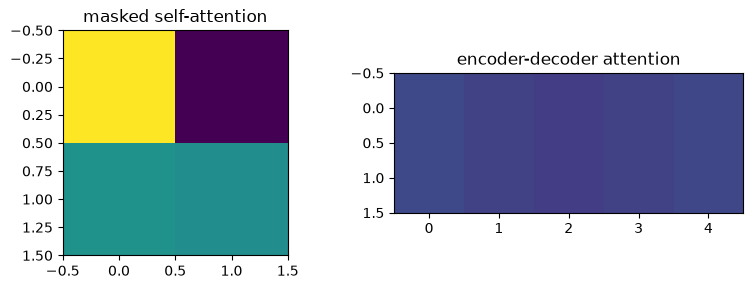

In [34]:
DE_TOKENS = ["Ich", "studiere"]
de_ids    = encode(DE_TOKENS, token2id)

def causal_mask(n):
    """True = 가려야 할 미래 시점 위치."""
    return np.triu(np.ones((n, n), dtype=bool), k=1)

def init_decoder_layer(d_model, n_heads, d_ff, seed=0):
    return {"self_mha":  init_mha_params(d_model, n_heads, seed),
            "cross_mha": init_mha_params(d_model, n_heads, seed + 50),
            "ffn": init_ffn_params(d_model, d_ff, seed + 100),
            "g1": np.ones(d_model), "b1": np.zeros(d_model),
            "g2": np.ones(d_model), "b2": np.zeros(d_model),
            "g3": np.ones(d_model), "b3": np.zeros(d_model)}

def decoder_layer(Y, enc_out, p):
    """마스크드 self-attention -> cross-attention -> FFN."""
    self_attn, w_self = multi_head_attention(Y, Y, p["self_mha"], mask=causal_mask(Y.shape[0]))
    h1 = layer_norm(Y + self_attn, p["g1"], p["b1"])
    cross_attn, w_cross = multi_head_attention(h1, enc_out, p["cross_mha"])
    h2 = layer_norm(h1 + cross_attn, p["g2"], p["b2"])
    f = feed_forward(h2, p["ffn"])
    out = layer_norm(h2 + f, p["g3"], p["b3"])
    return out, w_self, w_cross

print("인과 마스크 (True = 가림)\n", causal_mask(4))
Y_dec = make_encoder_input(de_ids, E_FULL, PE)
dec_params = [init_decoder_layer(D_MODEL, N_HEADS, D_FF, seed=1000 + s) for s in range(N_LAYERS)]
Yh = Y_dec
for li in range(N_LAYERS):
    Yh, w_self, w_cross = decoder_layer(Yh, ENC_OUT, dec_params[li])
DEC_OUT = Yh

print("\n디코더 최종 출력 :", DEC_OUT.shape)
print("\n[마스크드 셀프 어텐션 가중치]\n", np.round(w_self[0], 3))
print("\n[인코더-디코더 어텐션 가중치] 모양 :", w_cross[0].shape)
print(np.round(w_cross[0], 3))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(w_self[0], cmap="viridis", vmin=0, vmax=1); axes[0].set_title("masked self-attention")
axes[1].imshow(w_cross[0], cmap="viridis", vmin=0, vmax=1); axes[1].set_title("encoder-decoder attention")
plt.tight_layout(); plt.show()


In [35]:
# ===== Q7 채점 =====
_m = causal_mask(3)
assert _m.dtype == bool and _m.shape == (3, 3)
assert np.array_equal(_m, np.array([[False, True, True], [False, False, True], [False, False, False]]))
assert DEC_OUT.shape == (2, D_MODEL)
assert np.allclose(w_self[0], np.tril(w_self[0])), "미래 시점 가중치는 0이어야 합니다"
assert np.allclose(w_self[0][0], [1.0, 0.0]), "첫 토큰은 자기 자신만 참조"
assert np.allclose(w_self[0].sum(axis=1), 1.0)
assert w_cross[0].shape == (2, 5), "인코더-디코더 어텐션은 (디코더 토큰 수, 인코더 토큰 수)"
assert np.allclose(w_cross[0].sum(axis=1), 1.0)
assert len(w_self) == N_HEADS and len(w_cross) == N_HEADS
assert np.allclose(DEC_OUT.mean(axis=-1), 0.0, atol=1e-5), "마지막에 층 정규화가 적용되어야 합니다"

# 마스크가 실제로 '미래 정보 차단'을 하는지: 두 번째 토큰을 바꿔도 첫 토큰의 출력은 그대로여야 함
_Y2 = Y_dec.copy(); _Y2[1] += 3.0
_o_a, _, _ = decoder_layer(Y_dec, ENC_OUT, dec_params[0])
_o_b, _, _ = decoder_layer(_Y2,  ENC_OUT, dec_params[0])
assert np.allclose(_o_a[0], _o_b[0]), "미래 토큰이 바뀌어도 현재 시점 출력은 변하면 안 됩니다"
print("✅ Q7 통과")

✅ Q7 통과


---
# Q8. 출력층 · 손실 함수 · 초모수와 파라미터 수

강의자료 요약
- 디코더의 **마지막(두 번째) 벡터**를 선형 층에 넣어 임베딩 벡터를 **어휘 차원(37,000)** 으로 확장한다. (가중치 512 × 37,000)
- 소프트맥스로 확률로 바꾼 뒤, **가장 높은 원소에 해당하는 토큰**을 출력한다.
- 초모수(어텐션 헤드 수, 인코더 반복 횟수, 임베딩 차원 등)는 **연구자가 정하는 자유 변수**이며, 값이 커질수록 정확도는 높아질 수 있으나 **계산량이 수직적으로 증가**한다.

### 요구사항
1. `output_projection(h_last, W_vocab)` + `softmax` 로 다음 토큰의 확률 분포를 구하고, `argmax` 로 예측 토큰 id를 구한다.
2. `cross_entropy(probs, target_id)` : 정답 토큰에 대한 교차 엔트로피 손실 $-\log p_{target}$.
3. `count_params(d_model, n_heads, d_ff, n_layers, vocab)` : 편향을 제외한 학습 가능 파라미터 수를 dict 로 반환.
   - 인코더 층 1개 = $4d^2$(어텐션) + $2 d \cdot d_{ff}$(FFN) + $2\cdot 2d$(층 정규화)
   - 디코더 층 1개 = $8d^2$ + $2 d \cdot d_{ff}$ + $3 \cdot 2d$
   - 임베딩 $V \cdot d$ + 출력 선형 $d \cdot V$
4. `d_model` 을 128 / 256 / 512 / 1024 로 바꿔가며 **파라미터 수가 어떻게 증가하는지** 그래프로 확인하고, 2배 늘렸을 때 몇 배가 되는지 답한다.

선형 층 가중치 : (512, 37000)
확률의 합 : 1.000000
예측 토큰 id : 28410, 확률 : 0.000177

정답 토큰 'Transformer' 의 확률 : 0.000042
교차 엔트로피 손실 : 10.0879
(학습 전이므로 손실은 log(V)=10.5187 근처)
encoder_layer        :    3,147,776
decoder_layer        :    4,197,376
encoder_total        :   18,886,656
decoder_total        :   25,184,256
embedding            :   18,944,000
output_projection    :   18,944,000
total                :   81,958,912
d_model=  128 -> 전체 파라미터   12,232,192
d_model=  256 -> 전체 파라미터   29,969,408
d_model=  512 -> 전체 파라미터   81,958,912
d_model= 1024 -> 전체 파라미터  251,998,208

d_model 을 256 -> 512 로 2배 늘리면 파라미터는 약 2.73배


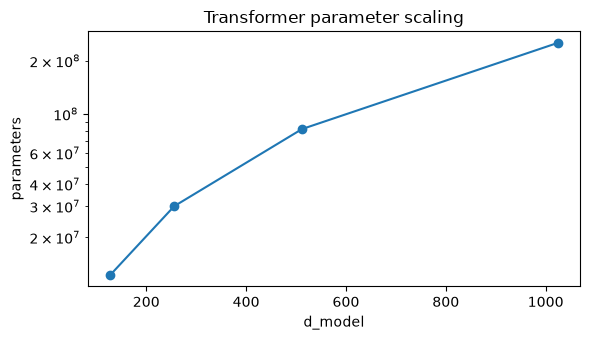

In [36]:
# ---- (1) 출력층 ----
W_VOCAB = (np.random.randn(D_MODEL, VOCAB_SIZE) * 0.02).astype(np.float32)

def output_projection(h_last, W_vocab):
    """디코더의 마지막 벡터 -> 어휘 차원 로짓."""
    return np.asarray(h_last) @ np.asarray(W_vocab)

logits  = output_projection(DEC_OUT[-1], W_VOCAB)
probs   = softmax(logits)
pred_id = int(np.argmax(probs))

print("선형 층 가중치 :", W_VOCAB.shape)
print("확률의 합 : %.6f" % probs.sum())
print("예측 토큰 id : %d, 확률 : %.6f" % (pred_id, probs[pred_id]))


def cross_entropy(probs, target_id, eps=1e-12):
    """정답 토큰에 대한 교차 엔트로피 손실."""
    return float(-np.log(np.clip(np.asarray(probs)[target_id], eps, None)))

target_id = token2id["Transformer"]
print("\n정답 토큰 'Transformer' 의 확률 : %.6f" % probs[target_id])
print("교차 엔트로피 손실 : %.4f" % cross_entropy(probs, target_id))
print("(학습 전이므로 손실은 log(V)=%.4f 근처)" % np.log(VOCAB_SIZE))


def count_params(d_model=512, n_heads=8, d_ff=2048, n_layers=6, vocab=37000):
    """편향을 제외한 학습 가능 파라미터 수."""
    encoder_layer = 4 * d_model ** 2 + 2 * d_model * d_ff + 4 * d_model
    decoder_layer = 8 * d_model ** 2 + 2 * d_model * d_ff + 6 * d_model
    embedding = vocab * d_model
    output_projection = d_model * vocab
    encoder_total = n_layers * encoder_layer
    decoder_total = n_layers * decoder_layer
    total = encoder_total + decoder_total + embedding + output_projection
    return {"encoder_layer": encoder_layer, "decoder_layer": decoder_layer,
            "encoder_total": encoder_total, "decoder_total": decoder_total,
            "embedding": embedding, "output_projection": output_projection,
            "total": total}

cnt = count_params()
for k, v in cnt.items():
    print(f"{k:20s} : {v:>12,}")

dims  = [128, 256, 512, 1024]
tots  = [count_params(d_model=d, d_ff=4 * d)["total"] for d in dims]
for d, t in zip(dims, tots):
    print(f"d_model={d:5d} -> 전체 파라미터 {t:>12,}")
ratio = tots[2] / tots[1]
print("\nd_model 을 256 -> 512 로 2배 늘리면 파라미터는 약 %.2f배" % ratio)

plt.figure(figsize=(6, 3.5))
plt.plot(dims, tots, "o-")
plt.xlabel("d_model"); plt.ylabel("parameters")
plt.yscale("log"); plt.title("Transformer parameter scaling")
plt.tight_layout(); plt.show()


In [37]:
# ===== Q8 채점 =====
assert logits.shape == (VOCAB_SIZE,) and probs.shape == (VOCAB_SIZE,)
assert np.isclose(probs.sum(), 1.0, atol=1e-4), "소프트맥스 결과의 합은 1"
assert pred_id == int(np.argmax(probs))
assert (probs >= 0).all()
assert np.isclose(cross_entropy(np.array([0.1, 0.9]), 1), -np.log(0.9))
assert cross_entropy(np.array([0.5, 0.5]), 0) > cross_entropy(np.array([0.1, 0.9]), 1), "확률이 높을수록 손실이 작다"

c = count_params()
assert c["encoder_layer"] == 3_147_776, "인코더 층 1개 = 4*512^2 + 2*512*2048 + 2*2*512"
assert c["decoder_layer"] == 4_197_376
assert c["embedding"] == 37000 * 512 and c["output_projection"] == 512 * 37000
assert c["total"] == 6 * 3_147_776 + 6 * 4_197_376 + 2 * 37000 * 512 == 81_958_912
assert count_params(d_model=256, d_ff=1024)["encoder_layer"] == 4 * 256 ** 2 + 2 * 256 * 1024 + 4 * 256
assert list(tots) == [count_params(d_model=d, d_ff=4 * d)["total"] for d in dims]
assert 2.0 < ratio < 4.0, "차원을 2배 늘리면 파라미터는 2배보다 훨씬 많이 늘어난다"
print("✅ Q8 통과")

✅ Q8 통과


---
# 종합 확인 — 전체 파이프라인

지금까지 만든 함수만으로 강의자료의 전체 흐름이 완성됩니다.

```
"I am studying Transformer."
   → 워드피스 토큰화 → 어휘 사전 id → (원 핫) → 워드 임베딩(512차원)   ... Q1, Q2
   → + 위치 인코딩(512차원)                                           ... Q3
   → [인코더 x 6]  멀티헤드 어텐션(8헤드) → 잔차+정규화 → FFN → 잔차+정규화   ... Q4, Q5, Q6
   → [디코더 x 6]  마스크드 셀프 어텐션 → 인코더-디코더 어텐션 → FFN         ... Q7
   → 선형(512 x 37,000) → 소프트맥스 → 다음 토큰 예측                      ... Q8
```

In [38]:
def transformer_forward(src_tokens, tgt_tokens, verbose=True):
    """토큰화된 입력 -> 다음 토큰 확률까지 한 번에 수행."""
    src_ids = encode(src_tokens, token2id)
    tgt_ids = encode(tgt_tokens, token2id)

    X = make_encoder_input(src_ids, E_FULL, PE)          # 임베딩 + 위치 인코딩
    for p in enc_params:                                 # 인코더 6회
        X, _ = encoder_layer(X, p)

    Y = make_encoder_input(tgt_ids, E_FULL, PE)
    for p in dec_params:                                 # 디코더 6회
        Y, _, _ = decoder_layer(Y, X, p)

    prob = softmax(output_projection(Y[-1], W_VOCAB))
    if verbose:
        print(f"입력(영어)   : {src_tokens}")
        print(f"현재까지(독) : {tgt_tokens}")
        print(f"인코더 출력  : {X.shape}   디코더 출력 : {Y.shape}")
        print(f"다음 토큰 확률 분포 : {prob.shape},  예측 id = {int(np.argmax(prob))}")
    return prob

_ = transformer_forward(TOKENS, DE_TOKENS)
print("\n🎉 모든 문제 완료! 강의자료의 트랜스포머 전체 구조를 직접 구현했습니다.")

입력(영어)   : ['I', 'am', 'study', '##ing', 'Transformer']
현재까지(독) : ['Ich', 'studiere']
인코더 출력  : (5, 512)   디코더 출력 : (2, 512)
다음 토큰 확률 분포 : (37000,),  예측 id = 28410

🎉 모든 문제 완료! 강의자료의 트랜스포머 전체 구조를 직접 구현했습니다.


---
## 제출 안내
1. 모든 `# TODO` 를 채우고 **위에서부터 순서대로** 셀을 실행하세요.
2. 각 채점 셀에서 `✅ Qn 통과` 가 모두 출력되어야 합니다.
3. `파일 > .ipynb 다운로드` 로 저장한 뒤 제출하세요.

### 생각해 볼 문제 답안

**(a) 위치 인코딩에 순서 번호나 원 핫 벡터를 그대로 쓰면 생기는 문제**

순서 번호를 그대로 더하면 문장 길이가 길어질수록 값의 크기가 계속 커져 토큰 임베딩의 의미를 압도할 수 있습니다. 또한 각 위치의 차이가 동일한 선형 값으로만 표현되어 다양한 상대적 거리와 주기를 표현하기 어렵습니다. 위치 원 핫 벡터는 최대 문장 길이를 미리 정해야 하고 위치 수만큼 차원이 증가해 메모리와 계산량이 커집니다. 사인·코사인 위치 인코딩은 제한된 범위의 값을 사용하면서 다양한 주기를 제공하고 더 긴 위치에도 확장할 수 있습니다.

**(b) 어텐션 점수를 $\sqrt{d_k}$로 나누는 이유**

쿼리와 키의 각 성분이 평균 0, 분산 1이라고 하면 내적의 분산은 대략 $d_k$에 비례해 커집니다. 따라서 차원이 커질수록 나누지 않은 점수는 큰 절댓값을 갖고 softmax가 한 위치에 지나치게 집중됩니다. 이 포화 상태에서는 대부분의 확률이 0에 가까워져 학습에 필요한 그래디언트가 약해집니다. $\sqrt{d_k}$로 나누면 점수의 분산을 일정한 수준으로 유지해 안정적인 어텐션 학습이 가능합니다.

**(c) 512차원 헤드 하나 대신 64차원 헤드 8개를 사용하는 이유**

각 헤드는 서로 다른 선형 투영을 학습해 문법, 의미, 장거리 관계처럼 서로 다른 관계를 볼 수 있습니다. 헤드별 계산은 독립적이므로 GPU에서 배치 행렬곱으로 병렬 처리할 수 있습니다. 8개의 64차원 결과를 연결하면 전체 표현력은 512차원으로 유지되므로 입력과 출력 차원을 바꾸지 않습니다. 하나의 512차원 헤드만 쓰는 것보다 다양한 관점의 관계를 동시에 표현할 수 있습니다.

**(d) 디코더에만 마스크가 필요한 이유**

인코더는 입력 문장 전체를 이미 알고 있으므로 각 토큰이 앞뒤의 모든 토큰을 참고하는 양방향 어텐션을 사용해도 됩니다. 반면 디코더는 실제 생성 시점에 아직 생성하지 않은 미래 토큰을 볼 수 없어야 합니다. 인과 마스크는 현재 위치보다 뒤에 있는 토큰을 가려 학습 조건을 실제 생성 조건과 일치시킵니다. 이 마스크가 없으면 정답 미래 토큰을 미리 보고 예측하게 되어 자기회귀 언어 모델의 학습 목적이 깨집니다.

**(e) 잔차 연결이 없을 때의 문제**

층이 깊어질수록 각 층의 변환을 연속으로 통과하면서 신호와 그래디언트가 약해지거나 특정 방향으로 왜곡될 수 있습니다. 잔차 연결은 각 블록이 입력 전체를 보존하면서 필요한 변화만 학습하도록 해 최적화를 쉽게 만듭니다. 또한 역전파에서 입력으로 직접 이어지는 경로를 제공해 기울기 소실을 완화합니다. 따라서 6층 이상의 트랜스포머를 안정적으로 학습하려면 잔차 연결이 매우 중요합니다.
